# 讨论热度分析 — Discussion Volume Analysis

Starter notebook for analyzing a keyword's discussion volume across Bilibili + Zhihu.

**How to use:**
1. Make sure you've already scraped data for your keyword: `python -m scraper scrape "<keyword>" --count 20`
2. Set `KEYWORD` below to whatever you scraped.
3. Kernel → Restart & Run All.

If a cell shows no data, you probably haven't scraped that keyword yet — open a terminal and run `python -m scraper status` to see what's in your DB.

In [1]:
# --- Configure here ---
KEYWORD = "国内新能源汽车"  # change to whatever you scraped

# Make sure we can import `scraper` and find `data/scraped.db` regardless of
# where the notebook was launched (Jupyter starts from the .ipynb's dir).
import os, sys, pathlib
repo_root = pathlib.Path.cwd()
while not (repo_root / 'scraper').is_dir() and repo_root.parent != repo_root:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))
os.chdir(repo_root)  # so 'data/scraped.db' (relative path in config.yaml) resolves

from scraper.analyze import (
    posts_for_keyword, answers_for_keyword, comments_for_post,
    volume_by_day, engagement_history, scrape_run_summary,
)
from scraper import viz
import pandas as pd

pd.set_option('display.max_colwidth', 80)

## 1. Quick overview — what do we have for this keyword?

In [2]:
runs = scrape_run_summary(keyword=KEYWORD)
print(f'Scrape runs for {KEYWORD!r}: {len(runs)}')
runs.head(10)

Scrape runs for '国内新能源汽车': 1


,运行ID,关键词,平台,请求数量,实际帖子数,实际评论数,开始时间,结束时间,错误信息
0,7,国内新能源汽车,zhihu,10,10,50,2026-05-11 21:36:43,2026-05-11 21:37:48,None


In [3]:
posts = posts_for_keyword(KEYWORD)
answers = answers_for_keyword(KEYWORD)
print(f'Direct hits (questions/videos): {len(posts)}')
print(f'  by platform: {posts["平台"].value_counts().to_dict()}')
print(f'Nested answers under those questions: {len(answers)}')

Direct hits (questions/videos): 10
  by platform: {'zhihu_question': 10}
Nested answers under those questions: 50


## 2. Volume over time

When did this topic get hot? X-axis is the post's *publish* date, not when we scraped it — so it shows the timeline of when content was created, not collected.

In [4]:
daily = volume_by_day(KEYWORD)
daily

,日期,平台,帖子数,评论总数,点赞总数,收藏总数,播放总数
0,2022-06-04,zhihu_question,1,4082,0,6133,26495270
1,2022-09-28,zhihu_question,1,184,0,418,1524924
2,2024-01-14,zhihu_question,1,1681,0,4161,19647335
3,2024-04-16,zhihu_question,1,75,0,133,386364
4,2024-06-30,zhihu_question,1,13,0,17,5287
5,2024-09-22,zhihu_question,1,294,0,595,720674
6,2024-11-30,zhihu_question,1,614,0,859,4262023
7,2025-02-11,zhihu_question,1,54,0,86,104261
8,2025-06-01,zhihu_question,1,762,0,1108,8798309
9,2026-03-30,zhihu_question,1,26,0,24,5111


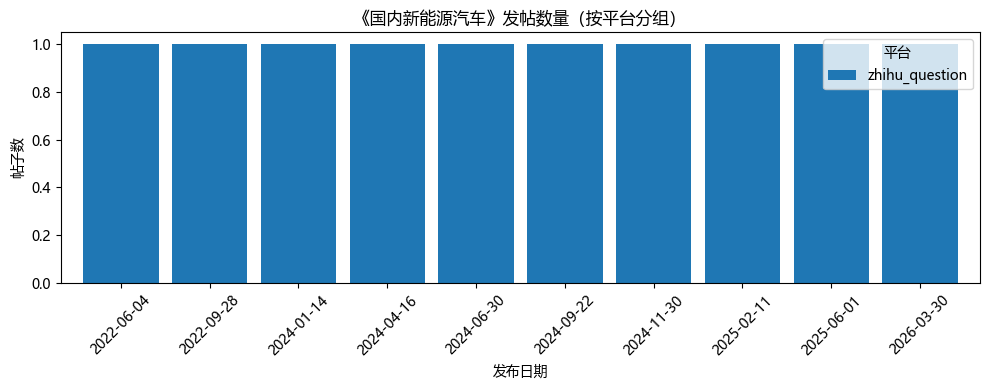

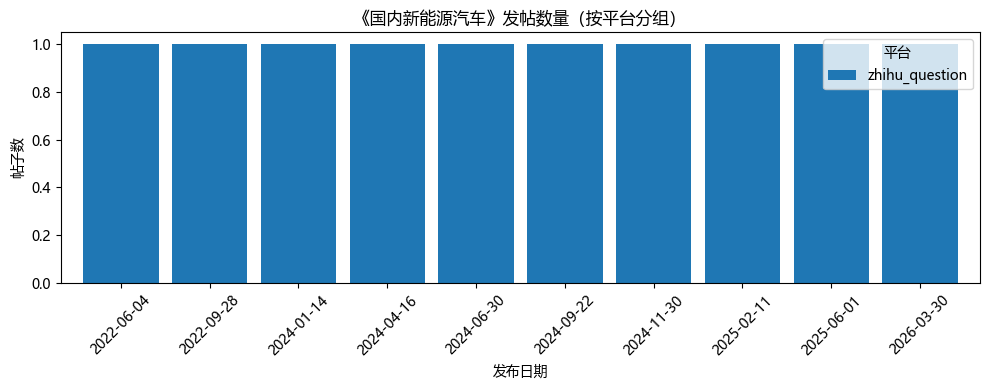

In [5]:
viz.volume_chart(KEYWORD)

## 3. Top posts — what's actually getting attention?

In [6]:
# Tabular view — sort by your metric of choice
cols = ['平台', '帖子ID', '标题', '评论数量', '点赞数量', '播放数量']
available_cols = [c for c in cols if c in posts.columns]
(posts[available_cols]
   .sort_values(['评论数量','点赞数量'], ascending=False)
   .head(15))

,平台,帖子ID,标题,评论数量,点赞数量,播放数量
9,zhihu_question,536080693,为什么现在还有这么多人在拼命唱衰新能源车？,4082,None,26495270
7,zhihu_question,639536083,外资车企被我国新能源汽车卷哭了吗？,1681,None,19647335
1,zhihu_question,1912465197551034730,为什么到处都在宣传用了新能源车就回不去了？,762,None,8798309
3,zhihu_question,5595143867,新能源车为何在欧美不受欢迎，在国内却是蓬勃发展？,614,None,4262023
4,zhihu_question,667863742,新能源汽车行业会不会像房地产一样一地鸡毛?,294,None,720674
8,zhihu_question,556113838,为什么中国不断推行新能源汽车？,184,None,1524924
6,zhihu_question,653119932,未来3-5年，新能源汽车最终剩下的会有几家？,75,None,386364
2,zhihu_question,11897745216,中国的新能源汽车是不是发展错方向了？,54,None,104261
0,zhihu_question,2022052323422218187,26年选车国产新能源还是合资杂牌电车？,26,None,5111
5,zhihu_question,660332651,为什么国产新能源没那么好，全中国都在夸大新能源的好？,13,None,5287


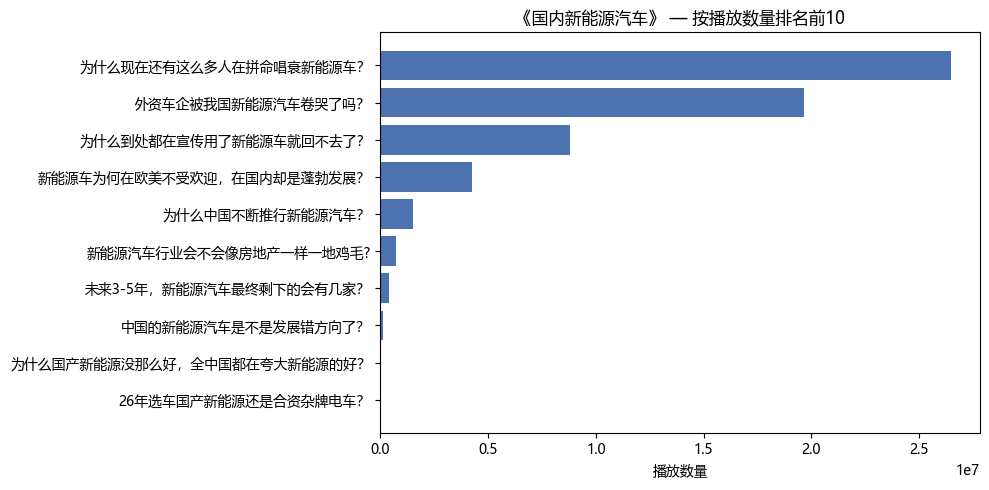

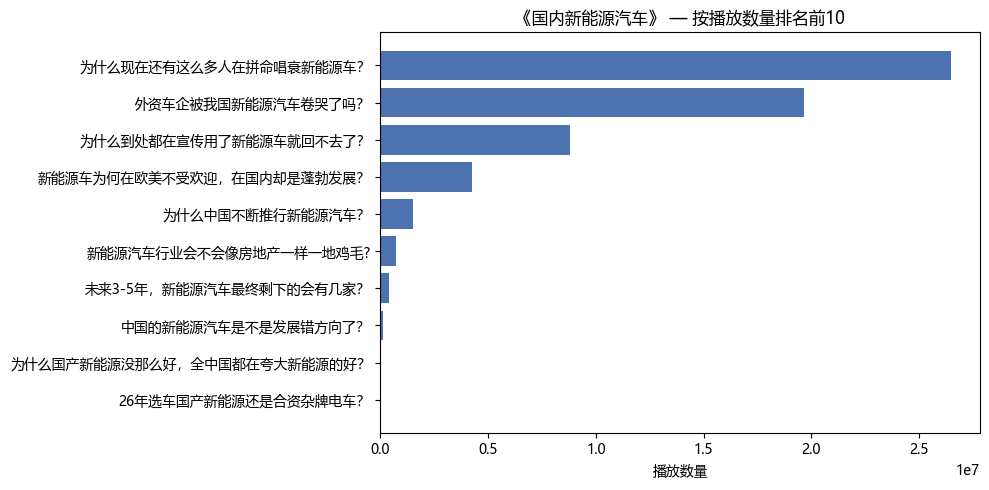

In [7]:
# Try different metrics: 评论数量, 点赞数量, 收藏数量, 播放数量, 转发数量
viz.top_posts(KEYWORD, metric='播放数量', n=10)

## 4. Engagement distribution — long tail or even spread?

Most posts get little attention; a few go viral. The histogram shape tells you whether this keyword has a clear "winners-take-all" dynamic or a more democratic distribution.

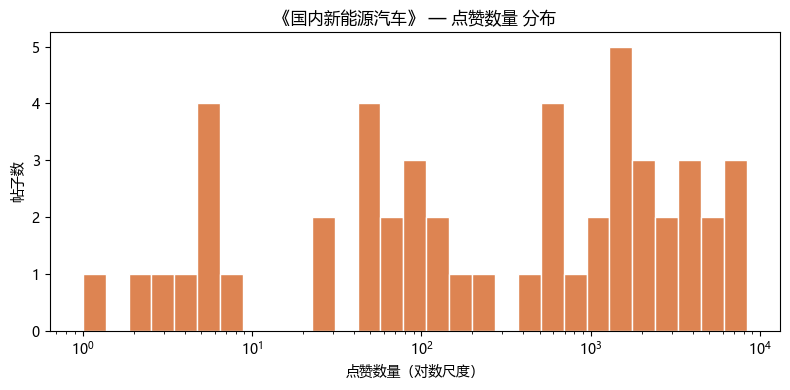

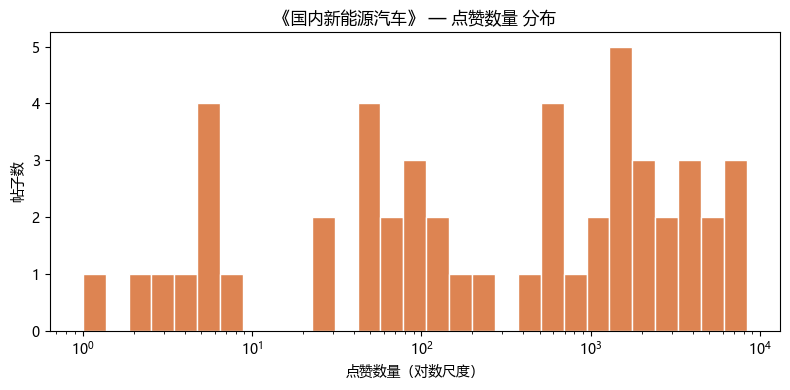

In [8]:
viz.engagement_distribution(KEYWORD, metric='点赞数量')

## 5. Bilibili vs. Zhihu — where is the discussion happening?

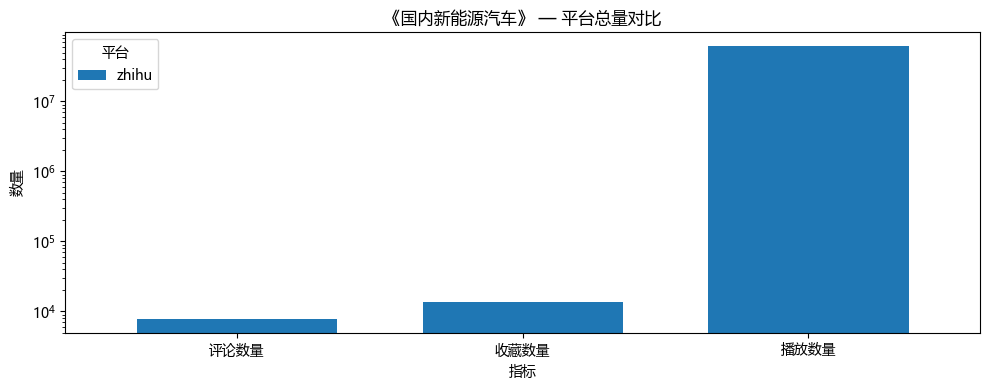

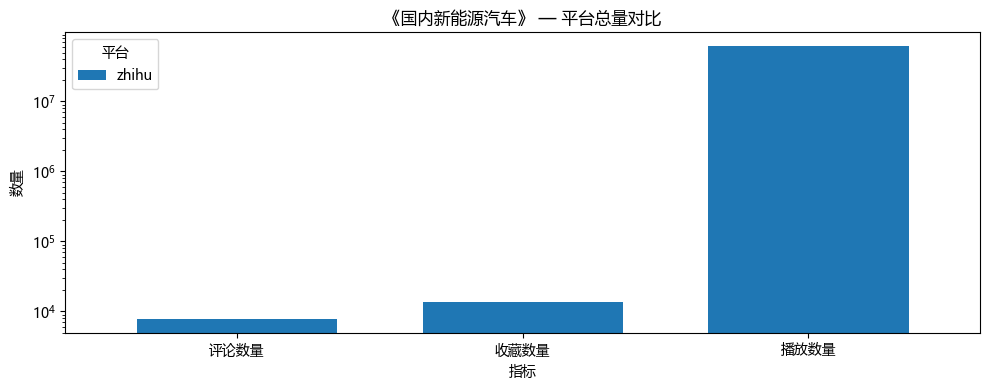

In [9]:
viz.platform_comparison(KEYWORD)

## 6. Sample answers/comments — what are people actually saying?

If you scraped with `--comments-per-answer`, this surfaces the top answer text. Useful for spot-checking before any text-based modeling.

In [10]:
# Top answers by vote
if not answers.empty:
    display(answers.sort_values('点赞数量', ascending=False)
           [['作者昵称','点赞数量','评论数量','内容']]
           .head(5))
else:
    print('No answers for this keyword — scrape with --answers-per-q to fetch some.')

,作者昵称,点赞数量,评论数量,内容
0,龙哥哥,8332,1040.0,很多人跟你说参数，什么多省油啊，加速多猛啊，内饰多豪华啊……不妨我带大家从另外一个角度切入看看为什么回不去了。\n我爸是个小包工头，手底下有十来个工仔，...
1,寡言得当,8027,2599.0,确实卷哭了。我这篇回答，会列举一些COEM让人欲哭无泪的骚操作。当然，我会隐去一些有明显指向性的信息。因为确实会被法务谈话。\n还是写在最前，能知道这本...
2,萨克麦迪克,7755,532.0,因为油车时代追求的东西：\n大马力，零百，换挡丝滑，静音，内饰，冰箱彩电，豪华沙发，低油耗，智能化。\n居然莫名其妙的被电车直接全部以廉价的方案搞定了。
3,王小六,5966,1172.0,因为欧美的户外充电桩，装上不用几天就会变成这个德行。这还是功率小的，功率大的，一个桩上整二斤铜还是没问题的。
4,哄哄,5115,706.0,上个月我约了表弟一家一起去郊游野炊。\n当我让我大儿子和我一起从我的Q7后备箱搬运拆卸煤炭袋、酒精引火块（这两东西又重又害怕破损，我还必须把这两个东西装...


In [11]:
# Comments on the top-voted answer (if any)
if not answers.empty:
    top_answer_id = answers.sort_values('点赞数量', ascending=False).iloc[0]['帖子ID']
    comments_df = comments_for_post(str(top_answer_id))
    print(f'Top answer ({top_answer_id}) has {len(comments_df)} captured comments')
    display(comments_df[['作者昵称','点赞数量','内容']].head(10))

Top answer (2004246024391263108) has 0 captured comments


,作者昵称,点赞数量,内容


## 7. Engagement growth (longitudinal)

Only meaningful after you've re-scraped the same posts at least twice. Set up a daily Task Scheduler job (`python -m scraper scrape "<keyword>" --count 20`) and after ~1 week the chart below will show whether each top post is still gaining traction or has plateaued.

In [12]:
# Pick the highest-engagement post and plot its metrics over time
if not posts.empty:
    top = posts.sort_values('评论数量', ascending=False).iloc[0]
    print(f'Tracking: {top["标题"][:80]!r}')
    history = engagement_history(str(top['帖子ID']))
    if len(history) > 1:
        viz.engagement_growth(str(top['帖子ID']))
    else:
        print(f'Only {len(history)} snapshot(s) — re-run the scrape on different days to build a time series.')

Tracking: '为什么现在还有这么多人在拼命唱衰新能源车？'
Only 1 snapshot(s) — re-run the scrape on different days to build a time series.


---
**Next steps**: explore the raw tables directly with pandas if you need more flexibility. The unified views are:
- `posts_unified` — cross-platform post table
- `comments_unified` — cross-platform comment table
- `keyword_posts_unified` — keyword → post linkage with run metadata

Use `from scraper.analyze import as_dataframe; df = as_dataframe('posts_unified')` for the full view.